In [2]:
from ctapipe.image import toymodel
import astropy.units as u

In [3]:
test_model = toymodel.RingGaussian(0*u.deg,0*u.deg,1*u.deg,0.1*u.deg)

In [4]:
test_model.pdf()

TypeError: RingGaussian.pdf() missing 2 required positional arguments: 'x' and 'y'

In [15]:
import numpy as np
import astropy.units as u
from ctapipe.image.toymodel import RingGaussian

# Define the parameters for the ring
x = 0 * u.m
y = 0 * u.m
radius = 1 * u.m
sigma = 0.1 * u.m

# Create the RingGaussian object
ring = RingGaussian(x, y, radius, sigma)



In [8]:
import numpy as np
import matplotlib.pyplot as plt

from ctapipe.io import EventSource

source = EventSource('/Users/vdk/muons2024/simtel_files/2024year_tuned_nooulier_reflectivity_additional/run101_muon.simtel.gz')

camgeom = source.subarray.tel[1].camera.geometry
    
center_xs = 0.3 * u.m
center_ys = 0.6 * u.m
radius = 0.3 * u.m
width = 0.05 * u.m

muon_model = toymodel.RingGaussian(
    x=center_xs,
    y=center_ys,
    radius=radius,
    sigma=width,
)

# testing with flashcam
#geom = prod5_mst_flashcam.camera.geometry
charge, _, _ = muon_model.generate_image(
    camgeom,
    intensity=1000,
    nsb_level_pe=5,
)

In [5]:
charge

NameError: name 'charge' is not defined

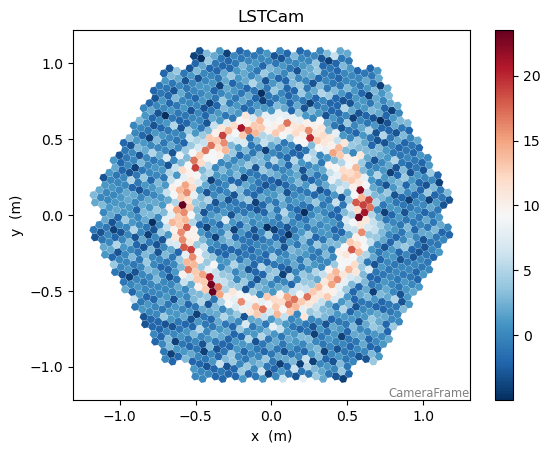

In [20]:
from ctapipe.visualization import CameraDisplay
center_xs = 0 * u.m
center_ys = 0 * u.m
radius = 0.6 * u.m
width = 0.06 * u.m

muon_model = toymodel.RingGaussian(
    x=center_xs,
    y=center_ys,
    radius=radius,
    sigma=width,
)

# testing with flashcam
#geom = prod5_mst_flashcam.camera.geometry
charge, _, _ = muon_model.generate_image(
    camgeom,
    intensity=1000,
    nsb_level_pe=5,
)
disp = CameraDisplay(camgeom, image=charge)
disp.cmap = plt.cm.RdBu_r
disp.add_colorbar()
disp.set_limits_percent(95)

plt.show()